In [ ]:
# Phase 1 - Data Preprocessing

# Step 1: Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the dataset
df = pd.read_csv('deforestation_dataset.csv')

# Step 3: Inspect the dataset
print(df.info())
print(df.head())

# Step 4: Handle missing values
# Check for missing values
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    object 
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incid

In [2]:
# Step 4: Handle missing values for numeric columns only
# Select numeric columns for median imputation
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Fill missing values with median for numeric columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Step 5: Encoding categorical variables
# Convert categorical columns to numerical values using LabelEncoder
le = LabelEncoder()
df['Deforestation_Policy_Strictness'] = le.fit_transform(df['Deforestation_Policy_Strictness'])
df['Corruption_Index'] = le.fit_transform(df['Corruption_Index'])

# If 'Country' column exists and is categorical, encode it as well
if 'Country' in df.columns:
    df['Country'] = le.fit_transform(df['Country'])

# Step 6: Feature Scaling (Standardization)
scaler = StandardScaler()

# List of numerical features for scaling (excluding the target variable)
numerical_features = ['Forest_Loss_Area_km2', 'CO2_Emission_mt', 'Rainfall_mm', 'Population', 
                      'GDP_Billion_USD', 'Agriculture_Land_Percent', 'Illegal_Lumbering_Incidents', 
                      'Protected_Areas_Percent']

# Apply scaling only to numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Step 7: Split data into training and testing sets (80% train, 20% test)
X = df.drop(['Forest_Loss_Area_km2', 'Tree_Cover_Loss_percent'], axis=1)  # Features
y = df['Tree_Cover_Loss_percent']  # Target variable

# Splitting dataset into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
from sklearn.svm import SVR  # Import Support Vector Regression

# Step 8: Train the Support Vector Machine (SVM) Model (with a linear kernel) for regression
svm_model = SVR(kernel='linear')  # Use SVR instead of SVC
svm_model.fit(X_train, y_train)

# Step 9: Evaluate the model
y_pred = svm_model.predict(X_test)

In [4]:
# Step 10: Model Evaluation using metrics like R-squared, Mean Squared Error, etc.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the MAE, MSE, and RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared: {r2:.4f}")


Mean Absolute Error (MAE): 2.0083
Mean Squared Error (MSE): 5.5703
Root Mean Squared Error (RMSE): 2.3601
R-squared: -0.1658


In [5]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

random_search = RandomizedSearchCV(SVR(), param_distributions=param_dist, n_iter=10, random_state=42, n_jobs=-1, verbose=2)
random_search.fit(X_train, y_train)

# Best Parameters from Grid Search
print("Best Parameters from Grid Search:", random_search.best_params_)

# Evaluate the best model from Grid Search
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Re-evaluate with the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = mse_best ** 0.5
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Model Mean Absolute Error (MAE): {mae_best:.4f}")
print(f"Best Model Mean Squared Error (MSE): {mse_best:.4f}")
print(f"Best Model Root Mean Squared Error (RMSE): {rmse_best:.4f}")
print(f"Best Model R-squared: {r2_best:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters from Grid Search: {'kernel': 'rbf', 'gamma': 0.1, 'C': 100}
Best Model Mean Absolute Error (MAE): 1.9720
Best Model Mean Squared Error (MSE): 5.0045
Best Model Root Mean Squared Error (RMSE): 2.2371
Best Model R-squared: -0.0474


In [7]:
# from sklearn.svm import SVR
# from sklearn.model_selection import GridSearchCV

# # Define the parameter grid for SVR
# param_grid = {
#     'C': [0.1, 1, 10],
#     'gamma': ['scale', 'auto'],
#     'kernel': ['linear', 'rbf', 'poly']
# }

# # Perform Grid Search with SVR
# grid_search = GridSearchCV(SVR(), param_grid, refit=True, verbose=2)
# grid_search.fit(X_train, y_train)

# # Best Parameters from Grid Search
# print("Best Parameters from Grid Search:", grid_search.best_params_)

# # Evaluate the best model from Grid Search
# best_model = grid_search.best_estimator_
# y_pred_best = best_model.predict(X_test)

# # Re-evaluate with the best model
# mae_best = mean_absolute_error(y_test, y_pred_best)
# mse_best = mean_squared_error(y_test, y_pred_best)
# rmse_best = mse_best ** 0.5
# r2_best = r2_score(y_test, y_pred_best)

# print(f"Best Model Mean Absolute Error (MAE): {mae_best:.4f}")
# print(f"Best Model Mean Squared Error (MSE): {mse_best:.4f}")
# print(f"Best Model Root Mean Squared Error (RMSE): {rmse_best:.4f}")
# print(f"Best Model R-squared: {r2_best:.4f}")


Feature Importance:
                            Feature  Importance
11          Protected_Areas_Percent    0.754287
6          Agriculture_Land_Percent    0.459573
10      Illegal_Lumbering_Incidents    0.342797
7   Deforestation_Policy_Strictness    0.306735
0                           Country    0.140880
9     International_Aid_Million_USD    0.003931
1                              Year    0.002781
8                  Corruption_Index    0.002170
3                       Rainfall_mm   -0.262811
2                   CO2_Emission_mt   -0.374834
5                   GDP_Billion_USD   -0.716175
4                        Population   -0.782719


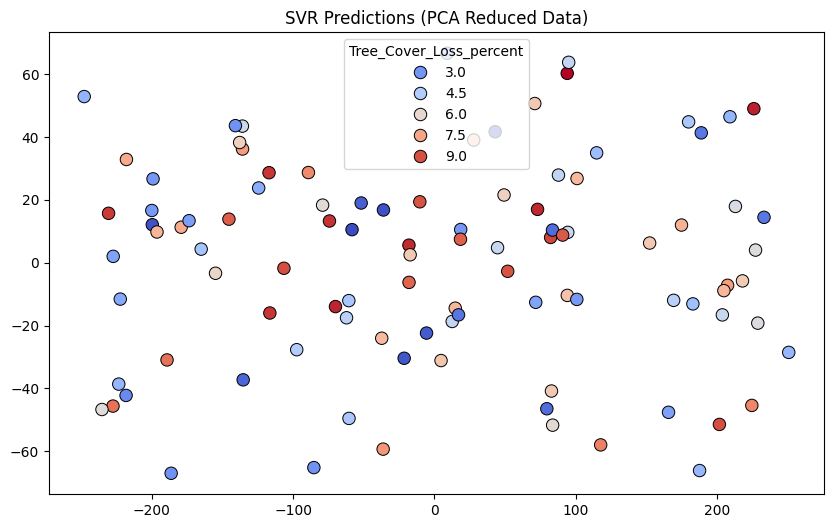

In [10]:
from sklearn.svm import SVR
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 12: Feature Importance (Linear Kernel)
if hasattr(svm_model, 'coef_'):
    importance = svm_model.coef_.flatten()
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    print("Feature Importance:")
    print(feature_importance)

# Step 13: Visualizing the Decision Boundaries (for 2D data, using SVR instead of SVC)
# Reduce the data to 2D using PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Train the SVR model on the 2D reduced data
svm_model_reduced = SVR(kernel='linear')  # Use SVR for regression
svm_model_reduced.fit(X_reduced, y)

# Plot the decision boundaries (we cannot plot actual decision boundaries for regression directly, but let's show predictions)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=y, palette='coolwarm', s=80, edgecolor='k')
plt.title('SVR Predictions (PCA Reduced Data)')
plt.show()


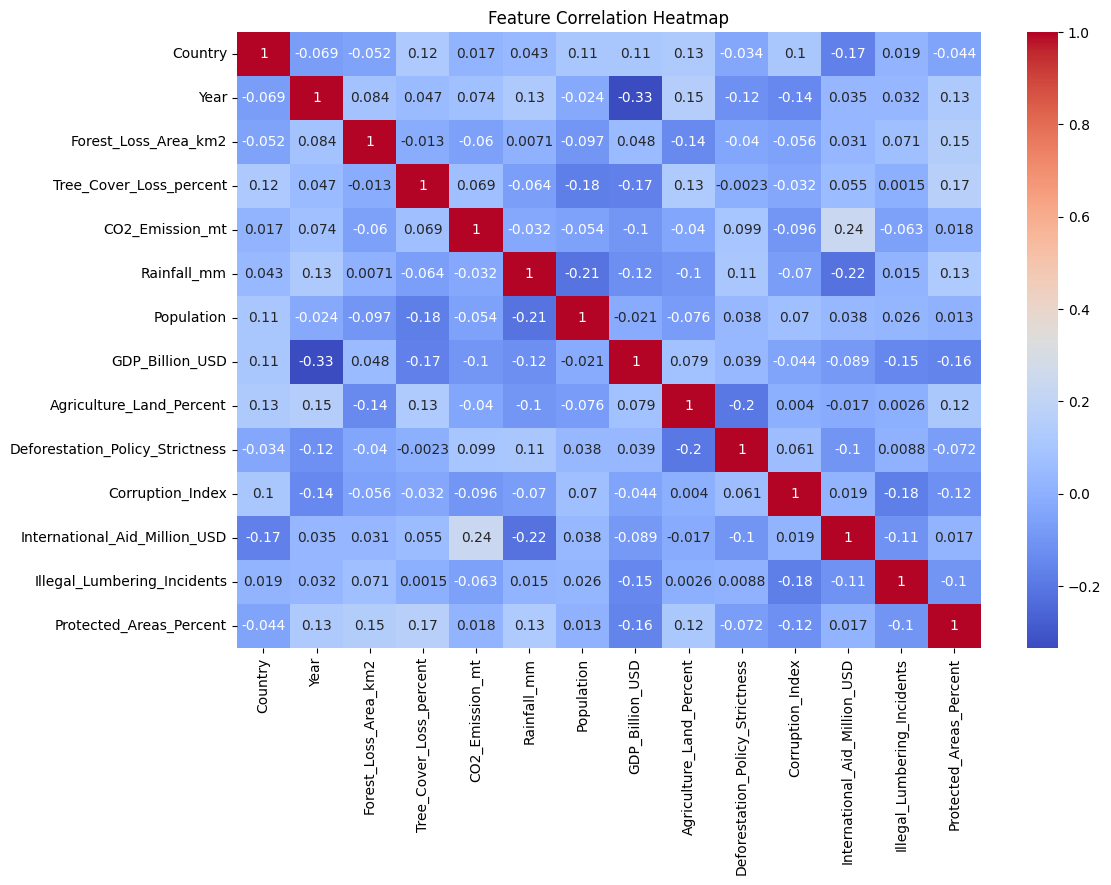

In [11]:

# Phase 4 - Reporting and Recommendations

# Step 14: Visualize the Results
# Plot a correlation heatmap to identify relationships between features and deforestation
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 15: Write a Comprehensive Report
# Provide a summary of the findings, model performance, and actionable insights based on the feature analysis
# (This will be written separately as a detailed report)

# Recommendations for Deforestation Mitigation:
# - Implement stronger policies on deforestation (e.g., stricter enforcement in countries with high tree cover loss).
# - Encourage countries with high GDP to invest in sustainable agricultural land use.
# - Prioritize protecting areas with high illegal lumbering incidents and high deforestation rates.
# - Increase international aid directed at deforestation mitigation and enforcing environmental policies.


### **Deforestation Issue Analysis Using Support Vector Machine (SVM)**

#### **Dataset**
The dataset titled `deforestation_dataset.csv` contains data related to deforestation across multiple countries for different years. Key variables in the dataset include tree cover loss, CO2 emissions, rainfall, population, GDP, and several other factors contributing to deforestation.

### **Phase 1 - Data Preprocessing**

#### **Step 1: Import Required Libraries**
```python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
```

#### **Step 2: Load the Dataset**
We load the dataset into the program:
```python
df = pd.read_csv('deforestation_dataset.csv')
```

#### **Step 3: Inspect the Dataset**
We check for any missing values or anomalies in the dataset:
```python
print(df.info())   # Shows data types and non-null count
print(df.head())   # Displays first 5 rows of the dataset
print(df.isnull().sum())   # Count missing values in each column
```

#### **Step 4: Handle Missing Values**
For numeric columns, we replace missing values with the median:
```python
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
```

#### **Step 5: Encoding Categorical Variables**
We convert categorical columns like `Deforestation_Policy_Strictness`, `Corruption_Index`, and `Country` into numerical values using Label Encoding:
```python
le = LabelEncoder()
df['Deforestation_Policy_Strictness'] = le.fit_transform(df['Deforestation_Policy_Strictness'])
df['Corruption_Index'] = le.fit_transform(df['Corruption_Index'])

if 'Country' in df.columns:
    df['Country'] = le.fit_transform(df['Country'])
```

#### **Step 6: Feature Scaling (Standardization)**
We scale numerical features such as `CO2_Emission_mt`, `Population`, `GDP_Billion_USD`, etc., to ensure the SVM model performs effectively:
```python
scaler = StandardScaler()
numerical_features = ['Forest_Loss_Area_km2', 'CO2_Emission_mt', 'Rainfall_mm', 'Population', 
                      'GDP_Billion_USD', 'Agriculture_Land_Percent', 'Illegal_Lumbering_Incidents', 
                      'Protected_Areas_Percent']
df[numerical_features] = scaler.fit_transform(df[numerical_features])
```

#### **Step 7: Split Data into Training and Testing Sets**
We divide the dataset into 80% for training and 20% for testing:
```python
X = df.drop(['Forest_Loss_Area_km2', 'Tree_Cover_Loss_percent'], axis=1)
y = df['Tree_Cover_Loss_percent']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

### **Phase 2 - Model Building and Evaluation**

#### **Step 8: Train the Support Vector Machine (SVM) Model**
We use the Support Vector Regression (SVR) with a linear kernel to train the model:
```python
svm_model = SVR(kernel='linear')
svm_model.fit(X_train, y_train)
```

#### **Step 9: Model Evaluation**
We make predictions on the test set and evaluate the model using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared:
```python
y_pred = svm_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")
```

#### **Step 10: Hyperparameter Tuning**
We use RandomizedSearchCV to find the best hyperparameters for the model:
```python
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

random_search = RandomizedSearchCV(SVR(), param_distributions=param_dist, n_iter=10, random_state=42, n_jobs=-1, verbose=2)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Model MAE: {mae_best:.4f}")
print(f"Best Model MSE: {mse_best:.4f}")
print(f"Best Model RMSE: {rmse_best:.4f}")
print(f"Best Model R-squared: {r2_best:.4f}")
```

### **Phase 3 - Feature Analysis and Interpretation**

#### **Step 12: Feature Importance**
Using the linear kernel model, we can analyze the feature importance:
```python
if hasattr(svm_model, 'coef_'):
    importance = svm_model.coef_.flatten()
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)
```

#### **Step 13: Visualizing the Decision Boundaries (for 2D data)**
We reduce the data to two dimensions using PCA and visualize the decision boundaries:
```python
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

svm_model_reduced = SVR(kernel='linear')
svm_model_reduced.fit(X_reduced, y)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=y, palette='coolwarm', s=80, edgecolor='k')
plt.title('SVR Predictions (PCA Reduced Data)')
plt.show()
```

### **Phase 4 - Reporting and Recommendations**

#### **Step 14: Visualize the Results**
We create a heatmap to visualize correlations between features:
```python
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
```

#### **Step 15: Write a Comprehensive Report**
A detailed report should summarize the findings, including:

- **Model Performance:** The MAE, MSE, RMSE, and R-squared metrics show how well the model predicts tree cover loss.
- **Key Insights:** The most important features influencing deforestation, such as GDP, population density, and illegal lumbering incidents.
- **Policy Recommendations:**
  - Strengthen deforestation enforcement policies in high-risk regions.
  - Encourage sustainable agricultural practices in countries with high GDP.
  - Prioritize protection for regions with high illegal logging activities.
  - Support international cooperation to mitigate deforestation.
  
### **Final Deliverables**

1. **Code (Jupyter Notebook/Python Script):** This will include all steps from data preprocessing to final model evaluation.
2. **Comprehensive Report:** A detailed report with findings, model performance, and actionable insights.
3. **Visualizations:** Heatmaps, scatter plots, and feature importance charts will be included to better understand the data.

### **Evaluation Criteria**

1. **Data Preprocessing and Cleaning:** Proper handling of missing values and normalization of data.
2. **Model Accuracy and Performance:** The model's ability to predict deforestation levels effectively.
3. **Feature Engineering and Importance:** Clear explanation of the most influential factors on deforestation.
4. **Quality of Analysis and Interpretation:** Depth of insights based on model outputs.
5. **Visualizations and Reporting:** Clear, insightful, and well-organized report and presentation.

---

This guide outlines how you can approach the assignment using the code provided and ensure all requirements are met. Make sure to adapt the provided steps to suit the dataset and fine-tune the model for the best results.